In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
plt.style.use('seaborn')
sns.set(font_scale=2)
import missingno as msno
import os

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.set_random_seed(777)
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_train = pd.read_csv('./data/train_a.csv')

In [3]:
df_train.tail()

,date&time,WashingMachine,Dryer,temp,icon,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
25891,2016-12-14 19:00,0.000850,0.003150,15.44,clear-night,0.67,10.00,Clear,15.44,1012.98,2.44,0.04,1481760000,224.0,0.0,6.43,0.0,1
25892,2016-12-14 20:00,0.002067,0.003150,14.11,clear-night,0.69,9.84,Clear,5.99,1012.14,5.06,0.24,1481763600,159.0,0.0,5.93,0.0,1
25893,2016-12-14 21:00,0.002450,0.003133,17.34,clear-night,0.64,10.00,Clear,17.34,1010.64,2.88,0.18,1481767200,123.0,0.0,7.16,0.0,1
25894,2016-12-14 22:00,0.002567,0.003433,18.26,partly-cloudy-night,0.64,9.98,Partly Cloudy,12.71,1009.88,3.65,0.42,1481770800,118.0,0.0,8.12,0.0,1
25895,2016-12-14 23:00,0.001983,0.003400,20.73,partly-cloudy-night,0.62,10.00,Partly Cloudy,11.14,1009.07,7.97,0.31,1481774400,204.0,0.0,9.88,0.0,1


In [4]:
train_data = [df_train]

icon_mapping = {'clear-day':0, 'clear-night':1, 'cloudy':2, 'fog':3, 'partly-cloudy-day':4, 'partly-cloudy-night':5, 'rain':6, 'snow':7, 'wind':8}
for dataset in train_data:
    dataset['icon'] = dataset['icon'].map(icon_mapping)

In [5]:
train_data = [df_train]

for dataset in train_data:
    dataset['time'] = dataset['date&time'].str.extract('(\d*[:]\d*)', expand=False)

In [6]:
df_train.drop(['date&time', 'visibility', 'summary', 'precipIntensity', 'precipProbability', 'icon', 'apparentTemperature', 'pressure', 'windSpeed', 
              'cloudCover', 'windBearing', 'dewPoint', 'WashingMachine'], axis=1, inplace=True)

In [7]:
time_mapping = {"0:00":0, "1:00":1, "2:00":2, "3:00":3, "4:00":4, "5:00":5, "6:00":6, "7:00":7, "8:00":8, "9:00":9, "10:00":10,
               "11:00":11, "12:00":12, "13:00":13, "14:00":14, "15:00":15, "16:00":16, "17:00":17, "18:00":18, "19:00":19, "20:00":20, "21:00":21, 
               "22:00":22, "23:00":23}
for dataset in train_data:
    dataset['time'] = dataset['time'].map(time_mapping)

In [8]:
df_train.head()

,Dryer,temp,hum,time,dayOfWeeks
0,0.005441,16.67,0.53,0.0,3
1,0.005317,16.19,0.52,1.0,3
2,0.005368,15.69,0.55,2.0,3
3,0.005527,15.29,0.58,3.0,3
4,0.005630,15.37,0.60,4.0,3


In [9]:
df_train['dayOfWeeks'].value_counts()

4    3720
3    3720
6    3696
5    3696
1    3696
0    3696
2    3672
Name: dayOfWeeks, dtype: int64

In [10]:
# 요일 별 분류

df_sun = df_train.loc[df_train['dayOfWeeks'] == 0]
df_mon = df_train.loc[df_train['dayOfWeeks'] == 1]
df_tue = df_train.loc[df_train['dayOfWeeks'] == 2]
df_wen = df_train.loc[df_train['dayOfWeeks'] == 3]
df_thu = df_train.loc[df_train['dayOfWeeks'] == 4]
df_fri = df_train.loc[df_train['dayOfWeeks'] == 5]
df_sat = df_train.loc[df_train['dayOfWeeks'] == 6]

In [11]:
dryer_mean = df_train['Dryer'].mean()
print(dryer_mean)
df_np = df_train.values.astype(np.float)
print(np.shape(df_np))

0.08210001295590054
(25896, 5)


In [12]:
df_np_hour = []
for i in range((int(len(df_np)/24))):
    df_np_hour.append(df_np[i*24:i*24+24])

In [13]:
np.shape(df_np_hour)

(1079, 24, 5)

In [14]:
delete_row = []

for i in range(len(df_np_hour)):
    cnt = 0
    for j in range(len(df_np_hour[i])):
        if(df_np_hour[i][j][0] < dryer_mean):
            cnt += 1
    
    if(cnt == 24):
        delete_row.append(i)


In [15]:
np.shape(df_np_hour)

(1079, 24, 5)

In [16]:
cnt = 0
for i in range(len(delete_row)):
    df_np_hour = np.delete(df_np_hour, (i - cnt), axis=0)
    cnt += 1

In [17]:
np.shape(df_np_hour)

(220, 24, 5)

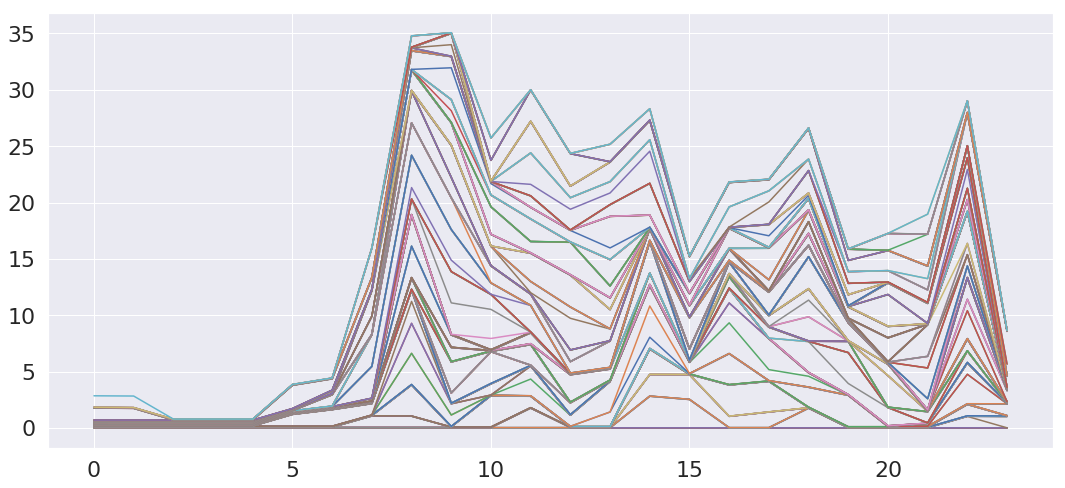

[ 2.  2.  0.  0.  0.  2.  4.  9. 18. 20. 16. 19. 14. 16. 15. 10. 13. 14.
 19. 12. 10. 12. 20.  6.]


In [18]:
pattern_priority = np.zeros(24)
pattern_count = np.zeros(24)

plt.figure(figsize=(18, 8))
for i in range(len(df_np_hour)):
    for j in range(len(df_np_hour[i])):
        pattern_priority[j] += df_np_hour[i][j][0]
        if(df_np_hour[i][j][0] > dryer_mean):
            pattern_count[j] += 1
    plt.plot(pattern_priority)
plt.show()

print(pattern_count)

In [19]:
df_all_np = []

for i in range(len(df_np_hour)):
    for j in range(len(df_np_hour[i])):
        temp = []
        for k in range(len(df_np_hour[i][j])):
            temp.append(df_np_hour[i][j][k])
        df_all_np.append(temp)

In [20]:
np.shape(df_all_np)

(5280, 5)

In [21]:
df_all_np = np.array(df_all_np)

In [22]:
scaler = MinMaxScaler()

device = df_all_np[:, 0:1]

temp = df_all_np[:, 1:2]
norm_temp = scaler.fit_transform(temp)

hum = df_all_np[:, 2:3]
norm_hum = scaler.fit_transform(hum)

time = df_all_np[:, 3:4]
norm_time = scaler.fit_transform(time)

day = df_all_np[:, -1:]
norm_day = scaler.fit_transform(day)

x = np.concatenate((norm_time, norm_temp, norm_hum, norm_day), axis=1)
print('x.shape ', x.shape)
print('x[0] ', x[0])
print('x[-1]', x[-1])

y = device
print('y[-1]', y[-1])

x.shape  (5280, 4)
x[0]  [0.04347826 0.42447169 0.59036145 1.        ]
x[-1] [1.         0.09639969 0.56626506 0.16666667]
y[-1] [0.0034]


In [23]:
train_size = int(len(x) * 0.7)
test_size = len(y) - train_size

trainX = np.array(x[0:train_size])
trainY = y[0:train_size]

testX = np.array(x[train_size:len(x)])
testY = y[train_size:len(y)]

print(np.shape(trainY))

(3695, 1)


In [24]:
X = tf.placeholder(tf.float32, [None, 4], name='X')
Y = tf.placeholder(tf.float32, [None, 1], name='Y')
W = tf.Variable(tf.random_normal([4, 1]), name='weight')
b = tf.Variable(tf.random_normal([1]), name='bias')

hypothesis = tf.matmul(X, W) + b

In [25]:
loss = tf.reduce_sum(tf.square(hypothesis - Y))
optimizer = tf.train.AdamOptimizer(0.0001)
train = optimizer.minimize(loss)

In [26]:
sess = tf.Session()
sess.run(tf.global_variables_initializer())

start_time = datetime.datetime.now()
print('학습 시작')
for epoch in range(20001):
    _, _loss, _H, _W, _b = sess.run([train, loss, hypothesis, W, b], feed_dict={X:trainX, Y:trainY})
        
    if(epoch % 1000 == 0):
        print(epoch, ' Cost : ', _loss, ', W : ', _W, ', b : ')

predictY = sess.run([hypothesis], feed_dict={X:testX})

print(predictY[0][0][0], testY[0][0])
print(np.shape(predictY), np.shape(testY))

학습 시작
0  Cost :  1674.8329 , W :  [[ 0.8025956 ]
 [ 0.67851293]
 [-1.2173831 ]
 [-0.3052686 ]] , b : 
1000  Cost :  1324.144 , W :  [[ 0.7151693]
 [ 0.5976149]
 [-1.2224452]
 [-0.3495231]] , b : 
2000  Cost :  1135.0624 , W :  [[ 0.6349824]
 [ 0.5291761]
 [-1.1077813]
 [-0.2973078]] , b : 
3000  Cost :  971.81915 , W :  [[ 0.55480516]
 [ 0.4600147 ]
 [-0.99660987]
 [-0.21160415]] , b : 
4000  Cost :  839.04803 , W :  [[ 0.47603887]
 [ 0.39208728]
 [-0.8914282 ]
 [-0.12387637]] , b : 
5000  Cost :  734.835 , W :  [[ 0.39910498]
 [ 0.32603136]
 [-0.7915292 ]
 [-0.04508548]] , b : 
6000  Cost :  654.8881 , W :  [[ 0.32410774]
 [ 0.26121706]
 [-0.6968592 ]
 [ 0.01822003]] , b : 
7000  Cost :  594.78656 , W :  [[ 0.25164086]
 [ 0.19711179]
 [-0.6072591 ]
 [ 0.05972155]] , b : 
8000  Cost :  550.7414 , W :  [[ 0.18309687]
 [ 0.13394302]
 [-0.52268356]
 [ 0.07636859]] , b : 
9000  Cost :  520.20325 , W :  [[ 0.12088912]
 [ 0.07280476]
 [-0.4434799 ]
 [ 0.07603527]] , b : 
10000  Cost :  501.2

In [27]:
predict_Y = []
for i in range(len(predictY[0])):
    predict_Y.append(predictY[0][i][0])

test_Y = []
for i in range(len(testY)):
    test_Y.append(testY[i][0])
    
np.shape(predict_Y), np.shape(testY)

((1585,), (1585, 1))

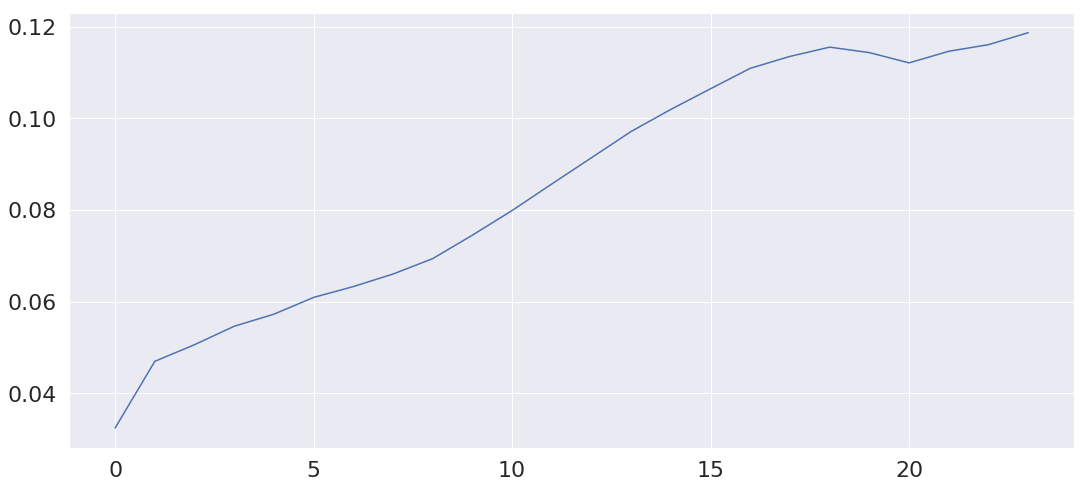

In [29]:
plt.figure(figsize=(18, 8))
plt.plot(predict_Y[:24])
plt.plot()
plt.show()